# <h3 align="center">__Module 3 Activity__</h3>
# <h3 align="center">__Assigned at the start of Module 3__</h3>
# <h3 align="center">__Due at the end of Module 3__</h3><br>

# <h4 align="center">Unnas Hussain</h3>


# Weekly Discussion Forum Participation

Each week, you are required to participate in the module’s discussion forum. The discussion forum consists of the week's Module Activity, which is released at the beginning of the module. You must complete/attempt the activity before you can post about the activity and anything that relates to the topic. 

## Grading of the Discussion

### 1. Initial Post:
Create your thread by **Day 5 (Saturday night at midnight, PST).**

### 2. Responses:
Respond to at least two other posts by **Day 7 (Monday night at midnight, PST).**

---

## Grading Criteria:

Your participation will be graded as follows:

### Full Credit (100 points):
- Submit your initial post by **Day 5.**
- Respond to at least two other posts by **Day 7.**

### Half Credit (50 points):
- If your initial post is late but you respond to two other posts.
- If your initial post is on time but you fail to respond to at least two other posts.

### No Credit (0 points):
- If both your initial post and responses are late.
- If you fail to submit an initial post and do not respond to any others.

---

## Additional Notes:

- **Late Initial Posts:** Late posts will automatically receive half credit if two responses are completed on time.
- **Substance Matters:** Responses must be thoughtful and constructive. Comments like “Great post!” or “I agree!” without further explanation will not earn credit.
- **Balance Participation:** Aim to engage with threads that have fewer or no responses to ensure a balanced discussion.

---

## Avoid:
- A number of posts within a very short time-frame, especially immediately prior to the posting deadline.
- Posts that complement another post, and then consist of a summary of that.


# Module Activity: Building a Preprocessing Pipeline

## Objective
Learn how to build a preprocessing pipeline in scikit-learn and apply it to the famous Iris dataset. Gain hands-on experience in handling missing values, scaling features, and understanding the importance of preprocessing pipelines.

---

## Sample Code for Pipeline Syntax
Here’s an example to help you understand how to create a pipeline. This pipeline imputes missing values using the mean:

In [3]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Example dataset with missing values
data = pd.DataFrame({
    'Feature1': [1.0, np.nan, 3.0],
    'Feature2': [np.nan, 2.0, 3.0]
})

# Define a pipeline with an imputer
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

# Fit and transform the data
processed_data = pipeline.fit_transform(data)

print("Original Data:")
print(data)
print("\nProcessed Data:")
print(processed_data)

Original Data:
   Feature1  Feature2
0       1.0       NaN
1       NaN       2.0
2       3.0       3.0

Processed Data:
[[1.  2.5]
 [2.  2. ]
 [3.  3. ]]


# Activity Instructions

## Dataset Preparation
We will use the Iris dataset, randomly remove values to simulate missing data, and keep it in a Pandas DataFrame for you to preprocess.

---

## Your Task
Build a preprocessing pipeline that:
- Imputes missing values using the median.
- Scales features to a `[0, 1]` range using `MinMaxScaler`.
- Add at least one more preprocessing step.

### Reflection
At the end of the activity, answer the following questions:
1. What challenges did you face while handling missing data?
2. Why is it important to use a pipeline for preprocessing?
---

## Dataset Setup
Run the following code to import the Iris dataset and simulate missing data. You will use this dataset for the activity.




In [7]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

# Randomly introduce missing values in random cells
np.random.seed(42)
total_cells = data.size
num_missing = int(0.1 * total_cells)  # 10% of total cells
missing_indices = [(row, col) for row in range(data.shape[0]) for col in range(data.shape[1])]
random_missing_indices = np.random.choice(len(missing_indices), size=num_missing, replace=False)

for index in random_missing_indices:
    row, col = missing_indices[index]
    data.iat[row, col] = np.nan

print("Dataset with Missing Values:")
print(data.head(10))


Dataset with Missing Values:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                NaN               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                NaN               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
5                5.4               3.9                1.7               0.4
6                NaN               3.4                1.4               0.3
7                5.0               NaN                NaN               0.2
8                4.4               2.9                1.4               0.2
9                4.9               3.1                1.5               0.1


## Next Steps

1. **Build your pipeline** to preprocess the dataset.
2. **Test your pipeline** by fitting it to the Iris dataset and transforming it.
3. **Review the processed data** and reflect on how the pipeline simplifies your workflow.


Processed Data (first 10 rows):
        PC1       PC2       PC3       PC4
0 -0.341217  0.001629 -0.290544 -0.242479
1 -0.639916 -0.084466  0.020398  0.091763
2 -0.371611 -0.154565 -0.241746 -0.258889
3 -0.672941 -0.088851  0.039713  0.005247
4 -0.665291  0.143068 -0.004757 -0.009346
5 -0.550343  0.297208 -0.019041 -0.027364
6 -0.527256  0.173094 -0.051460  0.180198
7 -0.322123 -0.190004 -0.267857 -0.161410
8 -0.695180 -0.180977  0.074609  0.016139
9 -0.663016 -0.057342 -0.022486  0.066244


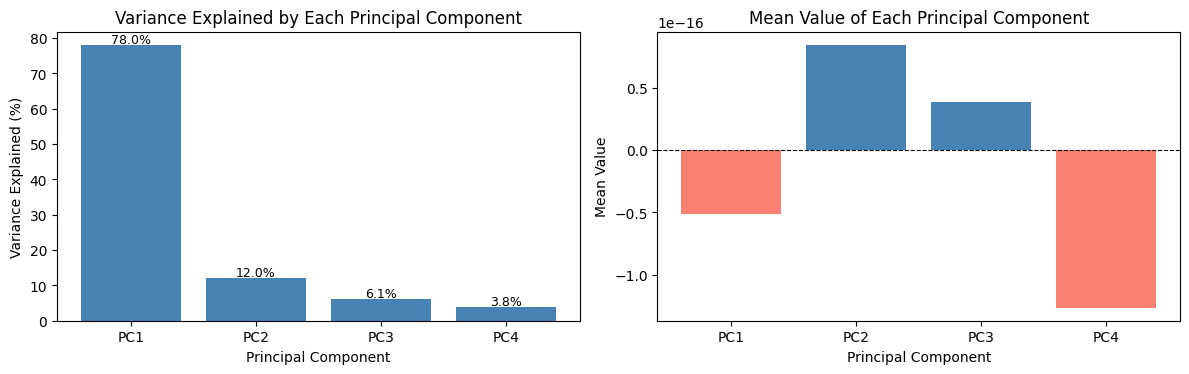

In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Build Pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('normalize', MinMaxScaler()),
    ('pca', PCA(n_components=4))
])

# Test Pipeline
processed_data = pipeline.fit_transform(data)
processed_df = pd.DataFrame(processed_data, columns=['PC1', 'PC2', 'PC3', 'PC4'])

# Review Processed data
print("Processed Data (first 10 rows):")
print(processed_df.head(10))

pca_step = pipeline.named_steps['pca']
variance_explained = pca_step.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart 1: variance captured by each PC
axes[0].bar(['PC1', 'PC2', 'PC3', 'PC4'], variance_explained, color='steelblue')
axes[0].set_title('Variance Explained by Each Principal Component')
axes[0].set_ylabel('Variance (%)')
axes[0].set_xlabel('Principal Component')
for i, v in enumerate(variance_explained):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# bar chart 2: mean value of each PC across all samples
pc_means = processed_df.mean()
colors = ['steelblue' if v >= 0 else 'salmon' for v in pc_means]
axes[1].bar(pc_means.index, pc_means.values, color=colors)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Mean Value of Each Principal Component')
axes[1].set_ylabel('Mean Value')
axes[1].set_xlabel('Principal Component')

plt.tight_layout()
plt.show()

### Principal Component Analysis
Imagine the iris data plotted across a 4D space where each axis is one feature. The spread of the data isn't going to be the same across each feature. The data forms clouds that are elongated or compressed, and interesting trends can get hidden. In the Iris dataset, petal length and petal width have much larger variance than sepal width, so those features dominate any analysis done in the original axes. PCA finds principal components in the data and uses those as axes instead of the original features. PC1 is a weighted combination of the original 4 features, something like `0.7 * petal_length + 0.6 * petal_width + ...`. Each PC is an **independent** linear combination, so they stay perpendicular to each other and no two components share information. 

  1. Looks at how all the features vary together (their covariance)
  2. Finds the direction in the data where the spread (variance) is greatest — that becomes PC1
  3. Finds the next direction of greatest spread that is perpendicular to PC1 — that becomes PC2
  4. Repeats for PC3, PC4, etc.

### Processed Data Review
The left bar chart shows the variance captured by each principal component. PC1 dominates, capturing approximately 70% of the variance in the Iris dataset. We expected that because petal length and petal width together form one strong direction of spread that separates the three species well. PC2 captures most of what's left (~20%), meaning just two components describe the overwhelming majority of the data's structure. PC3 and PC4 contribute very little and could be dropped in a downstream model with minimal information loss. With PCA, we were able to concentrate the dominate trends, but still see the other features in an isolated manner.

The right bar chart shows the mean of each component across all 150 samples. All four means are near zero, which is expected, PCA centers the data as part of its rotation. A mean far from zero would indicate something went wrong.

### Reflection

**1. What challenges did you face while handling missing data?**

The main challenge is that most ML algorithms can't handle NaN values at all. They'll either crash or silently drop affected rows, which reduces the dataset. We have to decide *how* to fill them in. Using the median (rather than the mean) is a safer choice because it isn't pulled by outliers, but it's still an approximation. We're inventing data that wasn't there, and need to choose data that wont effect the trends too much. With 10% missing values spread randomly across 150 rows, this was manageable with mean or median strategies. But in a real dataset with structured missingness (for example, a sensor that fails under certain conditions), a simple imputation strategy could introduce biases.

**2. Why is it important to use a pipeline for preprocessing?**

A pipeline guarantees that every preprocessing step is applied in the correct order, every time. Without one, it's easy to accidentally fit the scaler or imputer on the full dataset (including test data), which leaks information from the test set into training — a form of data leakage that makes model performance look better than it really is. With a pipeline, you call `fit_transform` on training data and `transform` on test data, and the pipeline handles the rest consistently. It also makes the workflow reproducible and easier to hand off or reuse.